In [1]:
import pandas as pd
import numpy as np  
import networkx as nx
import osmnx as ox
import geopandas as gpd
from shapely.geometry import box, Point
from shapely import wkt
import os
import matplotlib.pyplot as plt

In [2]:
# download graph data
bangkok_boundary = ox.geocode_to_gdf("Bangkok, Thailand")
graph = ox.graph_from_polygon(
    bangkok_boundary.geometry.iloc[0], 
    network_type="drive"
)

graph = ox.project_graph(graph) # lat/log to real distance
nodes, edges = ox.graph_to_gdfs(graph)  

### Incident Generation Grid

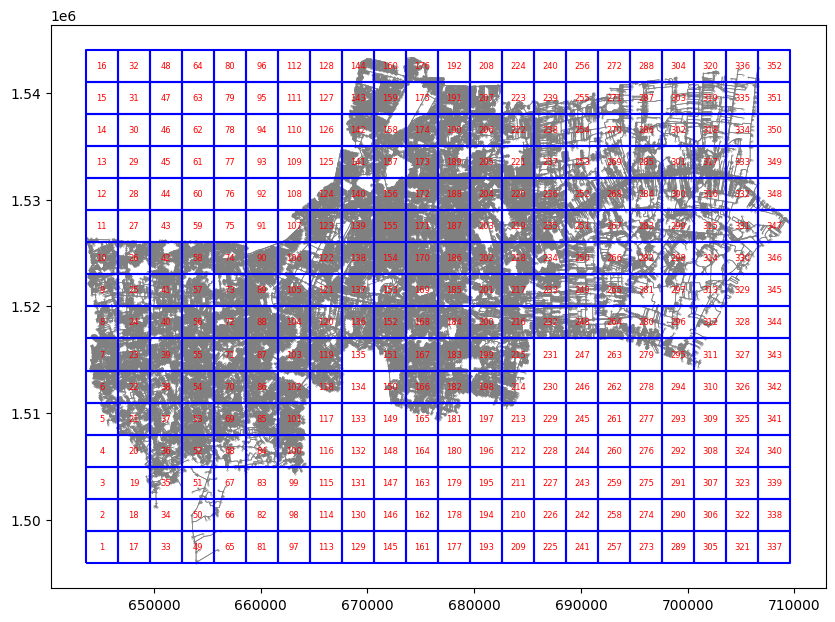

In [3]:
# Draw incient generation grids on Bangkok map
minx, miny, maxx, maxy = nodes.total_bounds

grid_size = 3000  
x_coords = np.arange(minx, maxx, grid_size)
y_coords = np.arange(miny, maxy, grid_size)

polygons = []
for x in x_coords:
    for y in y_coords:
        polygons.append(box(x, y, x + grid_size, y + grid_size))

grid = gpd.GeoDataFrame({'geometry': polygons}, crs=nodes.crs)

# add index to each grid cell 
grid["grid_id"] = range(1, len(grid) + 1,1)
grid["centroid"] = grid.geometry.centroid

#Plot 
fig, ax = plt.subplots(figsize=(10, 10))
nodes.plot(ax=ax, color='gray', markersize=0.1)
edges.plot(ax=ax, color='gray', linewidth=0.5)
grid.boundary.plot(ax=ax, edgecolor='blue')

# Add grid index
for idx, row in grid.iterrows():
    x, y = row["centroid"].x, row["centroid"].y
    ax.text(x, y, str(row["grid_id"]), fontsize=6, ha="center", va="center", color="red")

plt.show()


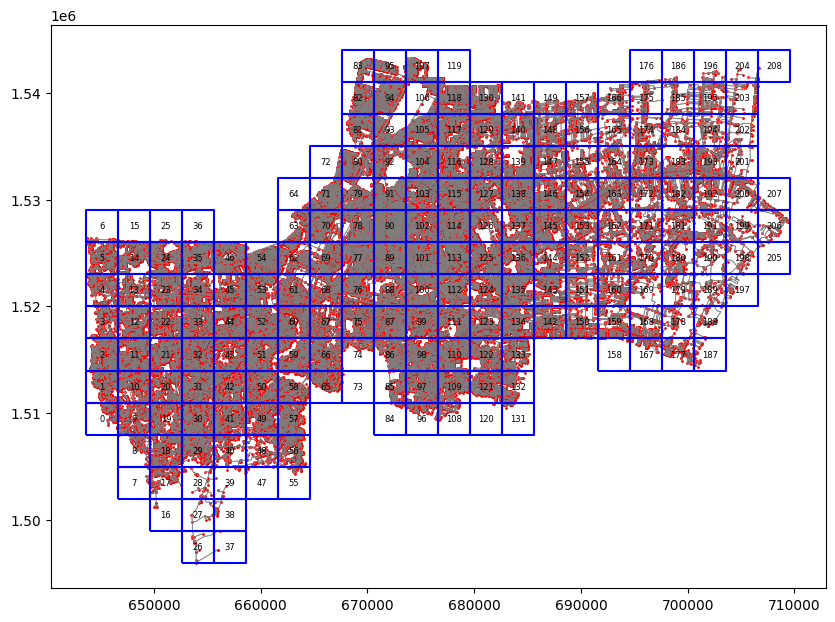

Number of grids left: 209


In [4]:
# remove grids with no nodes in it
grid_with_nodes = gpd.sjoin(grid, nodes, how="inner", predicate="contains").drop_duplicates(subset='grid_id')
grid_with_nodes = grid_with_nodes.reset_index(drop=True)
grid_with_nodes['grid_id'] = grid_with_nodes.index

# Plot
fig, ax = plt.subplots(figsize=(10, 10))
edges.plot(ax=ax, color="gray", linewidth=0.5)
nodes.plot(ax=ax, color="red", markersize=1)
grid_with_nodes.boundary.plot(ax=ax, edgecolor="blue")

# add grid index
for idx, row in grid_with_nodes.iterrows():
    x, y = row["centroid"].x, row["centroid"].y
    ax.text(x, y, str(idx), fontsize=6, ha="center", va="center", color="black")

plt.show()

print("Number of grids left:", len(grid_with_nodes))

In [5]:
# delete edge boxes
grid_with_nodes = grid_with_nodes.drop(index=[6, 15, 25,36,64,72,119,176,186,196,204,208,207,205,197,187,158,131,120,84,73,55,47,37,38,39,16,7])

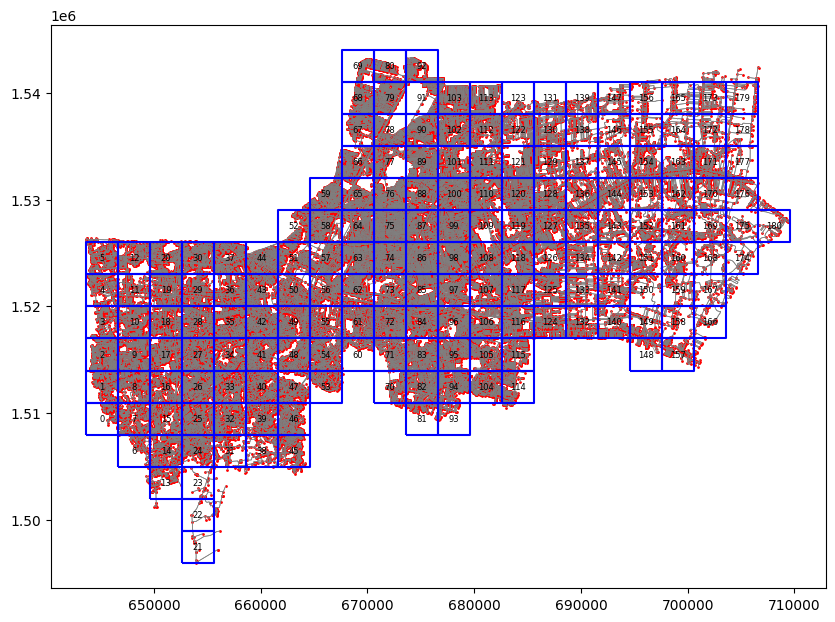

Number of grids left: 181


In [6]:
# plot new grid
grid_with_nodes = grid_with_nodes.reset_index(drop=True)
grid_with_nodes['grid_id'] = grid_with_nodes.index
# Plot 
fig, ax = plt.subplots(figsize=(10, 10))
edges.plot(ax=ax, color="gray", linewidth=0.5)
nodes.plot(ax=ax, color="red", markersize=1)
grid_with_nodes.boundary.plot(ax=ax, edgecolor="blue")

# add grid index
for idx, row in grid_with_nodes.iterrows():
    x, y = row["centroid"].x, row["centroid"].y
    ax.text(x, y, str(idx), fontsize=6, ha="center", va="center", color="black")

plt.show()

print("Number of grids left:", len(grid_with_nodes))

### Hospitals Data

In [7]:
# search hospitals
hospitals = {
    'amenity': [
        'hospital', 
        'โรงพยาบาล' 
    ],
    'healthcare': [
        'hospital',
        'โรงพยาบาล' 
    ],
    'building': [
        'hospital',
        'โรงพยาบาล'  
    ],
    'emergency': [
        'yes'  
    ]
}


# find hospitals inside Bangkok
hospitals = ox.features_from_polygon(
    bangkok_boundary.geometry.iloc[0],
    tags=hospitals
)

print(hospitals.head())
print("Number of hospitals:", len(hospitals))

# make sure nodes and hospitals have the same crs format
hospitals = hospitals.to_crs(nodes.crs) 

print("Hospitals")
print(hospitals.shape)  

                                      geometry   addr:city addr:postcode  \
element id                                                                 
node    340033055   POINT (100.48012 13.75294)  บางกอกน้อย         10700   
        340033080   POINT (100.47895 13.75541)         NaN           NaN   
        1402895609   POINT (100.56167 13.8939)         NaN           NaN   
        1797189361  POINT (100.53968 13.79234)         NaN           NaN   
        1872414783  POINT (100.43568 13.71252)         NaN           NaN   

                   addr:street   amenity healthcare  \
element id                                            
node    340033055   อิสรภาพ 44  hospital   hospital   
        340033080          NaN  hospital   hospital   
        1402895609         NaN  hospital   hospital   
        1797189361         NaN  hospital   hospital   
        1872414783         NaN  hospital        NaN   

                                          name  \
element id                     

In [8]:
# find nearest nodes to hospitals
hospitals_data = hospitals[['name']].reset_index(drop=True)
hospitals_data['centroid'] = hospitals.geometry.centroid.values

# add nearest node id
hospitals_data['nearest_node_id'] = hospitals_data['centroid'].apply(
   lambda centroid: ox.distance.nearest_nodes(graph, centroid.x, centroid.y)
)

# add node geometry (x,y)
hospitals_data['geometry'] = hospitals_data['nearest_node_id'].apply(
    lambda node_id: Point(graph.nodes[node_id]['x'], graph.nodes[node_id]['y'])
)

# Create geodataframe
hospitals_gdf = gpd.GeoDataFrame(
    hospitals_data,
    geometry='geometry',
    crs=nodes.crs
)

### Finding neighbour polygon and hospitals in the neighbour

In [9]:
# find toucing polygons of each incident generating polygons
for id in range(grid_with_nodes.shape[0]):
    polygon = grid_with_nodes.iloc[id].geometry
    grid_with_nodes[f'neighbor_to_{id}'] = grid_with_nodes.geometry.touches(polygon)

/home/thurein/ambo_allocate/lib/python3.13/site-packages/geopandas/geodataframe.py:1968: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)
/home/thurein/ambo_allocate/lib/python3.13/site-packages/geopandas/geodataframe.py:1968: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)
/home/thurein/ambo_allocate/lib/python3.13/site-packages/geopandas/geodataframe.py:1968: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many 

In [10]:
# neighbour to itself is True
for id in range(grid_with_nodes.shape[0]):
    grid_with_nodes.loc[id,f'neighbor_to_{id}'] = True

In [11]:
grid_with_nodes

,geometry,grid_id,centroid,osmid,y,x,street_count,highway,junction,ref,...,neighbor_to_171,neighbor_to_172,neighbor_to_173,neighbor_to_174,neighbor_to_175,neighbor_to_176,neighbor_to_177,neighbor_to_178,neighbor_to_179,neighbor_to_180
0,"POLYGON ((646622.224 1508001.071, 646622.224 1...",0,POINT (645122.224 1509501.071),8372039563,1.508643e+06,646620.068169,1,NaN,NaN,NaN,...,False,False,False,False,False,False,False,False,False,False
1,"POLYGON ((646622.224 1511001.071, 646622.224 1...",1,POINT (645122.224 1512501.071),5890205160,1.511009e+06,646515.984967,4,NaN,NaN,NaN,...,False,False,False,False,False,False,False,False,False,False
2,"POLYGON ((646622.224 1514001.071, 646622.224 1...",2,POINT (645122.224 1515501.071),4529622385,1.514001e+06,644060.158738,1,NaN,NaN,NaN,...,False,False,False,False,False,False,False,False,False,False
3,"POLYGON ((646622.224 1517001.071, 646622.224 1...",3,POINT (645122.224 1518501.071),5650696072,1.517006e+06,644846.524993,4,NaN,NaN,NaN,...,False,False,False,False,False,False,False,False,False,False
4,"POLYGON ((646622.224 1520001.071, 646622.224 1...",4,POINT (645122.224 1521501.071),5892026955,1.520014e+06,644595.340831,1,NaN,NaN,NaN,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
176,"POLYGON ((706622.224 1529001.071, 706622.224 1...",176,POINT (705122.224 1530501.071),6058787150,1.529148e+06,704073.521439,1,NaN,NaN,NaN,...,True,False,False,False,True,True,True,False,False,True
177,"POLYGON ((706622.224 1532001.071, 706622.224 1...",177,POINT (705122.224 1533501.071),8520619522,1.532004e+06,705096.856463,3,NaN,NaN,NaN,...,True,True,False,False,False,True,True,True,False,False
178,"POLYGON ((706622.224 1535001.071, 706622.224 1...",178,POINT (705122.224 1536501.071),6063908182,1.535010e+06,703625.856132,3,NaN,NaN,NaN,...,True,True,True,False,False,False,True,True,True,False
179,"POLYGON ((706622.224 1538001.071, 706622.224 1...",179,POINT (705122.224 1539501.071),11878828032,1.538084e+06,705246.485099,1,NaN,NaN,NaN,...,False,True,True,False,False,False,False,True,True,False


In [12]:
# Find the nearest hospital to each incident grid, to speed up the search we will only find hospitals within surrounding big polygons
grid_with_nodes['Neighbor_nodes'] = None
no_hospital_index = [] # collect nodes where there is no hosipital within the surrounding polygons

for i in range(grid_with_nodes.shape[0]): 
    neighbor_poly = grid_with_nodes['geometry'][grid_with_nodes[f'neighbor_to_{i}']] # retrieve all neighbor grids 
    multi_poly = neighbor_poly.union_all() # make one big polygon
    
    # Filter hospitals within the big poygon and get their node IDs
    hospital_nodes = hospitals_gdf[hospitals_gdf.geometry.within(multi_poly)]['nearest_node_id']
    
    if not hospital_nodes.empty:
        grid_with_nodes.at[i, 'Neighbor_nodes'] = hospital_nodes.tolist()
    else:
        no_hospital_index.append(i)
        grid_with_nodes.at[i, 'Neighbor_nodes'] = []  # Empty list if no hospitals
    
print(no_hospital_index)


/home/thurein/ambo_allocate/lib/python3.13/site-packages/geopandas/geodataframe.py:1968: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)


[45, 114, 129, 137, 142, 143, 144, 145, 151, 152, 153, 154, 155, 156, 159, 160, 161, 165, 167, 168, 169, 173, 174, 175, 179, 180]


In [13]:
# for simplicity we will drop incident generation grids with no hospitals in surrounding polygon
grid_with_nodes = grid_with_nodes.drop(index=no_hospital_index)
grid_with_nodes.reset_index(drop=True, inplace=True)
grid_with_nodes['grid_id'] = grid_with_nodes.index

In [14]:
grid_with_nodes = grid_with_nodes[['geometry','centroid','Neighbor_nodes']]
grid_with_nodes

,geometry,centroid,Neighbor_nodes
0,"POLYGON ((646622.224 1508001.071, 646622.224 1...",POINT (645122.224 1509501.071),"[4525663008, 5891920613]"
1,"POLYGON ((646622.224 1511001.071, 646622.224 1...",POINT (645122.224 1512501.071),"[4525663008, 3802835463, 5891920613]"
2,"POLYGON ((646622.224 1514001.071, 646622.224 1...",POINT (645122.224 1515501.071),"[4525663008, 3802835463]"
3,"POLYGON ((646622.224 1517001.071, 646622.224 1...",POINT (645122.224 1518501.071),"[8135223600, 3802835463]"
4,"POLYGON ((646622.224 1520001.071, 646622.224 1...",POINT (645122.224 1521501.071),[8135223600]
...,...,...,...
150,"POLYGON ((703622.224 1532001.071, 703622.224 1...",POINT (702122.224 1533501.071),[1669526676]
151,"POLYGON ((703622.224 1535001.071, 703622.224 1...",POINT (702122.224 1536501.071),[1669526676]
152,"POLYGON ((706622.224 1529001.071, 706622.224 1...",POINT (705122.224 1530501.071),[1669526676]
153,"POLYGON ((706622.224 1532001.071, 706622.224 1...",POINT (705122.224 1533501.071),[1669526676]


In [15]:
# assign nearest node to centrood of incident generation grid as incident generation point
grid_with_nodes['centroid'] = grid_with_nodes.geometry.centroid.values
grid_with_nodes['nearest_node_id'] = grid_with_nodes['centroid'].apply(
   lambda centroid: ox.distance.nearest_nodes(graph, centroid.x, centroid.y)
)

In [ ]:
grid_with_nodes.head()

,geometry,centroid,Neighbor_nodes,nearest_node_id
0,"POLYGON ((646622.224 1508001.071, 646622.224 1...",POINT (645122.224 1509501.071),"[4525663008, 5891920613]",4774432711
1,"POLYGON ((646622.224 1511001.071, 646622.224 1...",POINT (645122.224 1512501.071),"[4525663008, 3802835463, 5891920613]",4774391636
2,"POLYGON ((646622.224 1514001.071, 646622.224 1...",POINT (645122.224 1515501.071),"[4525663008, 3802835463]",4531080497
3,"POLYGON ((646622.224 1517001.071, 646622.224 1...",POINT (645122.224 1518501.071),"[8135223600, 3802835463]",4266198117
4,"POLYGON ((646622.224 1520001.071, 646622.224 1...",POINT (645122.224 1521501.071),[8135223600],8323046538
...,...,...,...,...
150,"POLYGON ((703622.224 1532001.071, 703622.224 1...",POINT (702122.224 1533501.071),[1669526676],5831688866
151,"POLYGON ((703622.224 1535001.071, 703622.224 1...",POINT (702122.224 1536501.071),[1669526676],6066499915
152,"POLYGON ((706622.224 1529001.071, 706622.224 1...",POINT (705122.224 1530501.071),[1669526676],6058786078
153,"POLYGON ((706622.224 1532001.071, 706622.224 1...",POINT (705122.224 1533501.071),[1669526676],8649892242


### Random incident rate assignment to incident generation nodes

In [17]:
# incident rate
random_seed = 42
rng = np.random.default_rng(seed = random_seed)
mean_rate_0 = rng.integers(low=0, high=3, size=50)
mean_rate_1= rng.integers(low=3, high=5, size=30)
mean_rate_2 = rng.integers(low=5, high=7, size=10)
mean_rate = list(mean_rate_0)+list(mean_rate_1)+list(mean_rate_2)


minultes_per_day = 1440
print(f"mean total incidents = {np.sum(mean_rate)}")

grid_id = rng.choice(range(grid_with_nodes.shape[0]),size = 90)
print(f"grid id to allocate = {grid_id}")

grid_with_nodes['mean_rate'] = np.zeros(grid_with_nodes.shape[0])
for id,rate in zip (grid_id,mean_rate):
    grid_with_nodes.loc[id,'mean_rate'] = rate

#add very high rate to incident area 24 and 53
grid_with_nodes.loc[27,'mean_rate'] = 7
grid_with_nodes.loc[40,'mean_rate'] = 10
grid_with_nodes.loc[55,'mean_rate'] = 7


mean total incidents = 217
grid id to allocate = [ 67 124 130  60 139  44  37 105  98  21 129  30 124   1 123 121 120 103
  73 109  42 121  86  71  78  88   5  21  38  17  68 103 101  73 132  87
  12 118  89  98  87  85  14  86 123  47  93   4  53  67 152  33  42  63
 153 132   5  36 127   9 132  43 142  45  67 102  19  86  78 121 154 102
  63  62  64 126  49  25  51   3  16  13 119 111 107  71 111  24 139  77]


In [18]:
print(len(mean_rate))

90


In [ ]:
grid_with_nodes.head()

,geometry,centroid,Neighbor_nodes,nearest_node_id,mean_rate
0,"POLYGON ((646622.224 1508001.071, 646622.224 1...",POINT (645122.224 1509501.071),"[4525663008, 5891920613]",4774432711,0.0
1,"POLYGON ((646622.224 1511001.071, 646622.224 1...",POINT (645122.224 1512501.071),"[4525663008, 3802835463, 5891920613]",4774391636,2.0
2,"POLYGON ((646622.224 1514001.071, 646622.224 1...",POINT (645122.224 1515501.071),"[4525663008, 3802835463]",4531080497,0.0
3,"POLYGON ((646622.224 1517001.071, 646622.224 1...",POINT (645122.224 1518501.071),"[8135223600, 3802835463]",4266198117,4.0
4,"POLYGON ((646622.224 1520001.071, 646622.224 1...",POINT (645122.224 1521501.071),[8135223600],8323046538,2.0
...,...,...,...,...,...
150,"POLYGON ((703622.224 1532001.071, 703622.224 1...",POINT (702122.224 1533501.071),[1669526676],5831688866,0.0
151,"POLYGON ((703622.224 1535001.071, 703622.224 1...",POINT (702122.224 1536501.071),[1669526676],6066499915,0.0
152,"POLYGON ((706622.224 1529001.071, 706622.224 1...",POINT (705122.224 1530501.071),[1669526676],6058786078,4.0
153,"POLYGON ((706622.224 1532001.071, 706622.224 1...",POINT (705122.224 1533501.071),[1669526676],8649892242,3.0


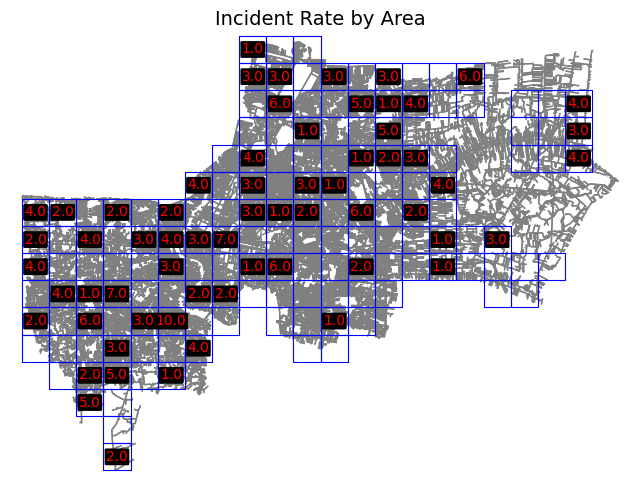

In [20]:
# Visulizing incident rates
fig, ax = ox.plot_graph(
    graph,
    show=False,
    close=False,
    bgcolor="white",   
    edge_color="gray",   
    node_color="gray",   
    node_size=0.1        
)

# Plot polygons 
grid_with_nodes.plot(
    ax=ax,
    facecolor="none",
    edgecolor="blue",
    linewidth=0.8
)

# Add incident rate text 
for idx, row in grid_with_nodes.iterrows():
    centroid = row.geometry.centroid
    incident_rate = row["mean_rate"]
    if incident_rate != 0:
        ax.text(
            centroid.x,
            centroid.y,
            f"{incident_rate}",  
            ha="center",
            va="center",
            fontsize=10,
            color="red",
            bbox=dict(facecolor="black", edgecolor="none", alpha=1, boxstyle="round,pad=0.1")
        )

plt.title("Incident Rate by Area", fontsize=14)
plt.show()


### Ambulance Bases

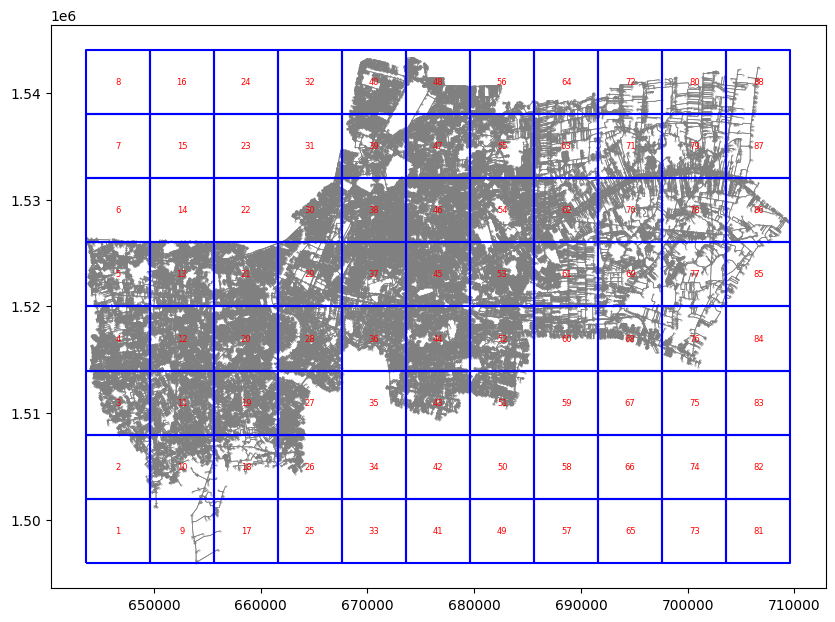

In [21]:
# Bangkok area is divided into 6000mx6000m grids and centriod of each grid is set as ambulance base location
minx, miny, maxx, maxy = nodes.total_bounds

base_grid_size = 6000
x_coords = np.arange(minx, maxx, base_grid_size)
y_coords = np.arange(miny, maxy, base_grid_size)

polygons = []
for x in x_coords[:]:
    for y in y_coords[:]:
        polygons.append(box(x, y, x + base_grid_size, y + base_grid_size))

base_grid = gpd.GeoDataFrame({'geometry': polygons}, crs=nodes.crs)

# --- Add IDs to each grid cell ---
base_grid["grid_id"] = range(1, len(base_grid) + 1)
base_grid["centroid"] = base_grid.geometry.centroid

# --- Plot everything ---
fig, ax = plt.subplots(figsize=(10, 10))
nodes.plot(ax=ax, color='gray', markersize=0.1)
edges.plot(ax=ax, color='gray', linewidth=0.5)
base_grid.boundary.plot(ax=ax, edgecolor='blue')

# Add grid numbers
for idx, row in base_grid.iterrows():
    x, y = row["centroid"].x, row["centroid"].y
    ax.text(x, y, str(row["grid_id"]), fontsize=6, ha="center", va="center", color="red")

plt.show()

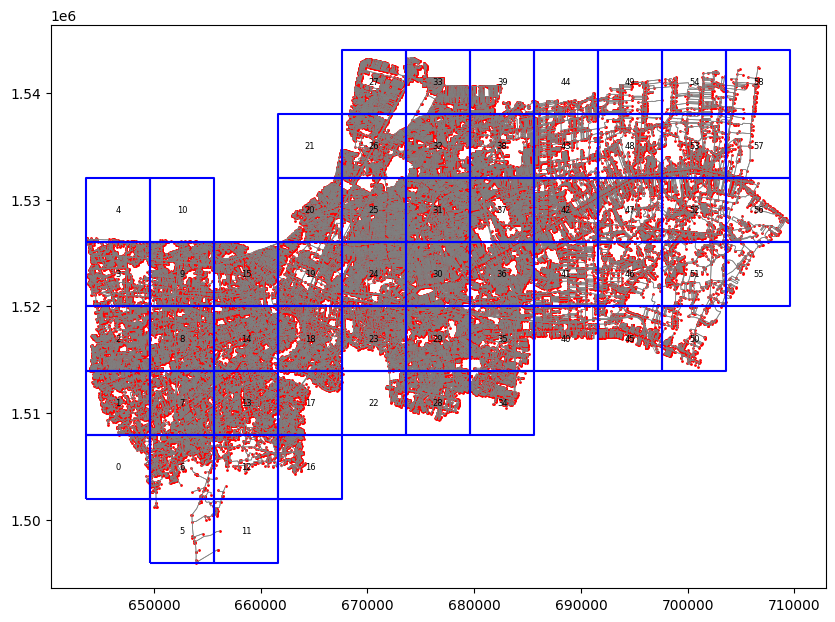

Number of grids left: 59


In [22]:
# remove grids with no nodes in it
base_grid_with_nodes = gpd.sjoin(base_grid, nodes, how="inner", predicate="contains").drop_duplicates(subset='grid_id')
base_grid_with_nodes = base_grid_with_nodes.reset_index(drop=True)
base_grid_with_nodes['grid_id'] = base_grid_with_nodes.index

# Plot
fig, ax = plt.subplots(figsize=(10, 10))
edges.plot(ax=ax, color="gray", linewidth=0.5)
nodes.plot(ax=ax, color="red", markersize=1)
base_grid_with_nodes.boundary.plot(ax=ax, edgecolor="blue")

# add grid index
for idx, row in base_grid_with_nodes.iterrows():
    x, y = row["centroid"].x, row["centroid"].y
    ax.text(x, y, str(idx), fontsize=6, ha="center", va="center", color="black")

plt.show()

print("Number of grids left:", len(base_grid_with_nodes))

In [23]:
# delete edge boxes
base_grid_with_nodes = base_grid_with_nodes.drop(index=[0,4,10,21,44,22,11])

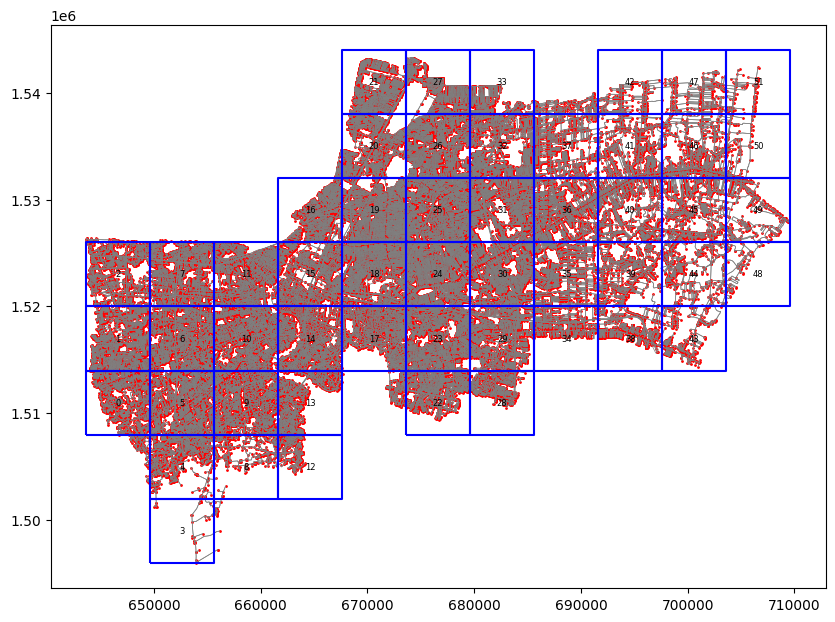

Number of grids left: 52


In [24]:
# plot new grid
base_grid_with_nodes = base_grid_with_nodes.reset_index(drop=True)
base_grid_with_nodes['grid_id'] = base_grid_with_nodes.index

fig, ax = plt.subplots(figsize=(10, 10))
edges.plot(ax=ax, color="gray", linewidth=0.5)
nodes.plot(ax=ax, color="red", markersize=1)
base_grid_with_nodes.boundary.plot(ax=ax, edgecolor="blue")

# Add numbers 
for idx, row in base_grid_with_nodes.iterrows():
    x, y = row["centroid"].x, row["centroid"].y
    ax.text(x, y, str(idx), fontsize=6, ha="center", va="center", color="black")

plt.show()

print("Number of grids left:", len(base_grid_with_nodes))

In [25]:
# assign centroid of grids to nearest nodes
base_grid_with_nodes['centroid'] = base_grid_with_nodes.geometry.centroid.values
base_grid_with_nodes['nearest_node_id'] = base_grid_with_nodes['centroid'].apply(
   lambda centroid: ox.distance.nearest_nodes(graph, centroid.x, centroid.y)
)

In [26]:
base_grid_with_nodes.head()

,geometry,grid_id,centroid,osmid,y,x,street_count,highway,junction,ref,railway,nearest_node_id
0,"POLYGON ((649622.224 1508001.071, 649622.224 1...",0,POINT (646622.224 1511001.071),5895538803,1.508005e+06,648222.594945,3,NaN,NaN,NaN,NaN,4775970225
1,"POLYGON ((649622.224 1514001.071, 649622.224 1...",1,POINT (646622.224 1517001.071),3492752716,1.514321e+06,649580.638932,4,NaN,NaN,NaN,NaN,4190995398
2,"POLYGON ((649622.224 1520001.071, 649622.224 1...",2,POINT (646622.224 1523001.071),5892026955,1.520014e+06,644595.340831,1,NaN,NaN,NaN,NaN,8444410952
3,"POLYGON ((655622.224 1496001.071, 655622.224 1...",3,POINT (652622.224 1499001.071),8630796626,1.496131e+06,653992.446689,1,NaN,NaN,NaN,NaN,8430744579
4,"POLYGON ((655622.224 1502001.071, 655622.224 1...",4,POINT (652622.224 1505001.071),5910957732,1.502056e+06,654345.158878,3,NaN,NaN,NaN,NaN,8374351728


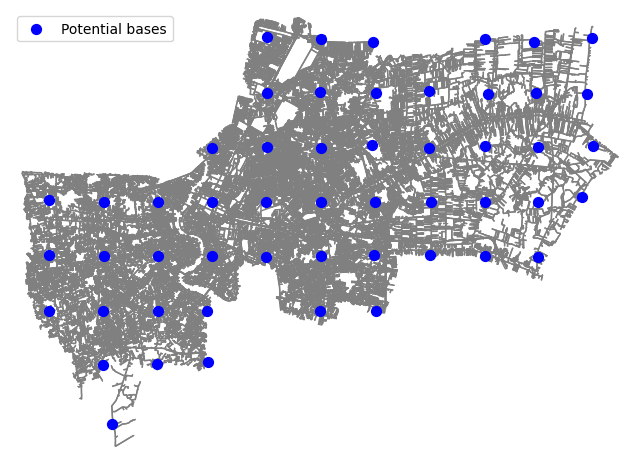

In [27]:
# Plot potential base nodes
fig, ax = ox.plot_graph(
    graph,
    show=False,
    close=False,
    bgcolor="white",     
    edge_color="gray",   
    node_color="gray",   
    node_size=0.1       
)

potential_ambulance_bases_nodes = base_grid_with_nodes['nearest_node_id'].to_list()
node_x = [graph.nodes[n]['x'] for n in potential_ambulance_bases_nodes]
node_y = [graph.nodes[n]['y'] for n in potential_ambulance_bases_nodes]

# Plot ambulance bases as red dots
ax.scatter(node_x, node_y, c="blue", s=50, marker="o", label="Potential bases")
plt.legend()

### Process and Save data

In [ ]:
# mean incident rates data
grid_with_nodes[['mean_rate']].to_csv("data/accident_rate.csv",index = False)

In [35]:
ambulance_bases = base_grid_with_nodes[['nearest_node_id']]
incident_areas  = grid_with_nodes[['nearest_node_id']]

In [36]:
ambulance_bases.head()

,nearest_node_id
0,4775970225
1,4190995398
2,8444410952
3,8430744579
4,8374351728


In [ ]:
# Pre processing Distance form bases to incidents

# Eucledian heuristics
ambulance_bases = base_grid_with_nodes[['nearest_node_id']]
incident_locations  = grid_with_nodes[['nearest_node_id']]
def Eu_distance_nodes(node1_id, node2_id):
    node1_data = graph.nodes[node1_id]
    node2_data = graph.nodes[node2_id]
    dx = node2_data['x'] - node1_data['x']
    dy = node2_data['y'] - node1_data['y']
    return (dx**2 + dy**2)**0.5

distance_base_to_incident_df = pd.DataFrame()

for i in range(len(incident_locations)):
    incident_node_id = incident_locations.loc[i,'nearest_node_id'] 
    distance_incident_to_base = []

    # find nearest distances from an incident to each base
    for j in range(len(ambulance_bases)):
        base_node_id = ambulance_bases.loc[j,'nearest_node_id']

        # if there is road connection between base to incident, add actual road distance
        if nx.has_path(graph, source=incident_node_id, target=base_node_id):
            actual_min_distance = nx.astar_path_length(
                graph, incident_node_id, base_node_id, 
                heuristic= Eu_distance_nodes, weight='length'
            )
        else:
            # if there isn't, add 3xEucledian distance
            actual_min_distance = Eu_distance_nodes(incident_node_id,base_node_id) * 3
        distance_incident_to_base.append(actual_min_distance)
    distance_base_to_incident_df[f'incident_{i}'] = distance_incident_to_base


In [ ]:
# Save data
distance_base_to_incident_df.to_csv('data/distance_base_to_incident.csv')

In [ ]:
# Finding nearest bases to incident
nearest_place_df = pd.DataFrame()
nearest_base_list = []
for i in range(len(incident_areas)):
    nearest_base = np.argmin(distance_base_to_incident_df[f"incident_{i}"])
    print(nearest_base)
    nearest_base_list.append(nearest_base)
nearest_place_df['nearest_base'] = nearest_base_list

In [ ]:
# Find nearest hospital form an incident
# Then process hospitals to bases distance
# nearest incident to hospital data

hospital_to_base_distance_df = pd.DataFrame()
distance_data_store = [] 

ambulance_bases = base_grid_with_nodes[['nearest_node_id']]
incident_locations  = grid_with_nodes[['nearest_node_id']]
hospital_locations = grid_with_nodes[['Neighbor_nodes']] # there are multiple hospital nodes in each incidet location

# Find nearest hoispital from incident 
# Then find distances from this hospitals to every bases 


for i in range(len(incident_locations)):
    # find nearest hospital
    incident_node_id = incident_locations.loc[i,'nearest_node_id']
    hospitals_nodes = hospital_locations.loc[i,'Neighbor_nodes']
    hospital_distance = []
    for hospital_node_id in hospitals_nodes:
        if nx.has_path(graph, source=incident_node_id, target=hospital_node_id):
            actual_min_distance = nx.astar_path_length(graph, incident_node_id, hospital_node_id, 
                                                        heuristic= Eu_distance_nodes, weight='length')
        else:
            actual_min_distance = Eu_distance_nodes(incident_node_id,hospital_node_id) * 3

        hospital_distance.append(actual_min_distance)
    nearest_distance = np.min(hospital_distance)
    nearest_hospital_node_id = hospitals_nodes[np.argmin(hospital_distance)]
    distance_data_store.append(nearest_distance)

    distance_hospital_to_bases = []
    
    # finding hospital to bases
    for j in range(len(ambulance_bases)):
        base_node_id = ambulance_bases.loc[j,'nearest_node_id']
        if nx.has_path(graph, source=nearest_hospital_node_id, target=base_node_id):
            actual_min_distance = nx.astar_path_length(
                graph, nearest_hospital_node_id, base_node_id, 
                heuristic= Eu_distance_nodes, weight='length'
            )
        else:
            actual_min_distance = Eu_distance_nodes(nearest_hospital_node_id,base_node_id) * 3
        distance_hospital_to_bases.append(actual_min_distance)
    hospital_to_base_distance_df[f'incident_{i}_hospital'] = distance_hospital_to_bases # append to dataframe
nearest_place_df['nearest_hospital_distance'] = distance_data_store
# nearest_place_df have two information
#1) nearest base id from incident location 
# 2) nearest hosiptal distance from incident location


In [ ]:
# save data
nearest_place_df.to_csv('data/nearest_places_data.csv')
hospital_to_base_distance_df.to_csv('data/distance_hospital_to_base.csv')

In [ ]:
# save nearest_place_df
nearest_place_df.to_csv("nearest_place_data.csv", index=False)